# Load the Dataset

In [ ]:
from google.colab import files
uploaded = files.upload()

Saving uc3m-titulaciones-2023-24.xlsx to uc3m-titulaciones-2023-24.xlsx


In [ ]:
import os
os.listdir()

['.config', 'uc3m-titulaciones-2023-24.xlsx', 'sample_data']

In [ ]:
import pandas as pd

titulaciones = pd.read_excel("uc3m-titulaciones-2023-24.xlsx")

titulaciones.head()

,curso_academico,cod_universidad,des_universidad,cod_tipo_estudio,des_tipo_estudio,cod_tipo_unidad_responsable,des_tipo_unidad_responsable,cod_unidad_responsable,des_unidad_responsable,cod_titulacion,...,cod_idioma_extranjero,des_idioma_extranjero,precio_credito_1,precio_credito_2,precio_credito_3,precio_credito_4,precio_credito_5,precio_tutela,num_creditos_necesarios,num_creditos_ofertados
0,2023-24,36,Universidad Carlos III de Madrid,G,Grado,1,Centro,28041822,Facultad de Ciencias Sociales y Jurídicas. (Ge...,7700001,...,2,"Existen planes separados, uno de ellos en Inglés",16.92,40.02,82.30,113.71,NaN,NaN,120.0,186.0
1,2023-24,36,Universidad Carlos III de Madrid,G,Grado,1,Centro,28042292,Escuela Politécnica Superior. (Leganés),7700002,...,2,"Existen planes separados, uno de ellos en Inglés",19.43,45.25,92.86,128.57,NaN,NaN,120.0,998.0
2,2023-24,36,Universidad Carlos III de Madrid,G,Grado,1,Centro,28050461,Facultad de Ciencias Sociales y Jurídicas (Col...,2500030,...,0,No se oferta en idioma extranjero,16.92,40.02,82.30,113.71,NaN,NaN,240.0,549.0
3,2023-24,36,Universidad Carlos III de Madrid,G,Grado,1,Centro,28041822,Facultad de Ciencias Sociales y Jurídicas. (Ge...,2500030,...,2,"Existen planes separados, uno de ellos en Inglés",16.92,40.02,82.30,113.71,NaN,NaN,240.0,549.0
4,2023-24,36,Universidad Carlos III de Madrid,G,Grado,1,Centro,28042292,Escuela Politécnica Superior. (Leganés),2503783,...,1,Se oferta en Inglés,19.43,45.25,92.86,128.57,NaN,NaN,240.0,120.0


# Inspect the Structure

In [ ]:
print("Shape:", titulaciones.shape)

print("\nColumns:")
print(titulaciones.columns)

print("\nMissing values:")
print(titulaciones.isnull().sum())

titulaciones.info()

Shape: (180, 34)

Columns:
Index(['curso_academico', 'cod_universidad', 'des_universidad',
       'cod_tipo_estudio', 'des_tipo_estudio', 'cod_tipo_unidad_responsable',
       'des_tipo_unidad_responsable', 'cod_unidad_responsable',
       'des_unidad_responsable', 'cod_titulacion', 'des_titulacion',
       'cod_rama', 'des_rama', 'cod_interuniversitario',
       'des_interuniversitario', 'cod_rol_coordinacion',
       'des_rol_coordinacion', 'cod_impartido', 'des_impartido', 'anio_inicio',
       'cod_situacion_actual', 'des_situacion_actual',
       'cod_grado_presencialidad', 'des_grado_presencialidad',
       'cod_idioma_extranjero', 'des_idioma_extranjero', 'precio_credito_1',
       'precio_credito_2', 'precio_credito_3', 'precio_credito_4',
       'precio_credito_5', 'precio_tutela', 'num_creditos_necesarios',
       'num_creditos_ofertados'],
      dtype='object')

Missing values:
curso_academico                  0
cod_universidad                  0
des_universidad             

# Keep the Relevant Columns

In [ ]:
cols_keep = [
    "cod_titulacion",
    "des_titulacion",
    "cod_tipo_estudio",
    "des_tipo_estudio"
]

titul_clean = titulaciones[cols_keep].copy()

titul_clean.head()

,cod_titulacion,des_titulacion,cod_tipo_estudio,des_tipo_estudio
0,7700001,Grado Abierto UC3M en Ciencias Sociales y Huma...,G,Grado
1,7700002,Grado Abierto UC3M en Ingeniería,G,Grado
2,2500030,Grado en Administración de Empresas,G,Grado
3,2500030,Grado en Administración de Empresas,G,Grado
4,2503783,Grado en Ciencia e Ingeniería de Datos,G,Grado


# Remove Duplicate Programs

In [ ]:
titul_clean = titul_clean.drop_duplicates()

titul_clean.shape

(174, 4)

# Check Missing Values

In [ ]:
titul_clean.isnull().sum()

,0
cod_titulacion,0
des_titulacion,0
cod_tipo_estudio,0
des_tipo_estudio,0


# Clean Text Fields

In [ ]:
titul_clean["des_titulacion"] = titul_clean["des_titulacion"].str.strip()
titul_clean["des_tipo_estudio"] = titul_clean["des_tipo_estudio"].str.strip().str.upper()

# Add Index Column

In [ ]:
titul_clean = titul_clean.reset_index(drop=True)
titul_clean.insert(0, "titulacion_id", titul_clean.index + 1)

# Programs by study type

<Axes: xlabel='des_tipo_estudio'>

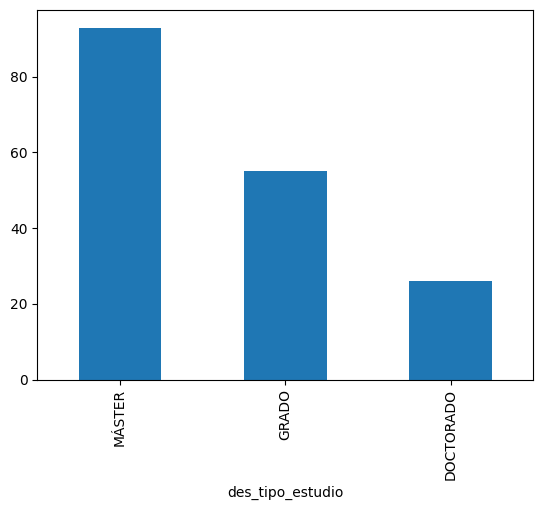

In [ ]:
titul_clean["des_tipo_estudio"].value_counts().plot(kind="bar")

# Save Dataset

In [ ]:
titul_clean.to_csv("titulaciones_clean.csv", index=False)

from google.colab import files
files.download("titulaciones_clean.csv")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>